# BUCSS 2026
## AI Session Hands-On Part 2: Training different models for Task 1

In this notebook you will:
- Load the training data
- Train AI models
- Vary station and model
- Note: Effect of history length is covered in the last cell

In [ ]:
import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
import shap
# import cmcrameri.cm as cmc
import random
# import statsmodels.api as sm
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler

#These are internal
import sys
sys.path.insert(0, "../scripts")
# print(sys.path)
from splitting_and_training import split_data, train_model, feature_selection, prepare_station_training_data, explain_model, calc_importance
from plotting import obs_map, plot_scatter_and_residuals, plot_stats, plot_importance, plot_shap_summary

random.seed(42)  # define seed to create deterministic results by pseudo-randomness


First we need to decide if we want every column in our dataframe as a feature in our ML model. 

In [2]:
def load_and_prepare_data(city="dortmund", station="DOBBHS"):
    """Loads dataframe

    Args:
        city (str): One of ["ghent", "dortmund"; "freiburg", "bern"]. Defaults to "dortmund".
        station (str). Station name, e.g. "DOBBHS" for dortmund or "BEL_GNE_001" for ghent
    """
    # 1) Load data
    df = pd.read_parquet(f"../dataframes_for_training/{city}_training.parquet")

    hod = df["datetime_utc"].dt.hour
    doy = df["datetime_utc"].dt.dayofyear
    df["tod_sin"] = np.sin(2 * np.pi * hod / 24)
    df["tod_cos"] = np.cos(2 * np.pi * hod / 24)
    df["doy_sin"] = np.sin(2 * np.pi * doy / 365)
    df["doy_cos"] = np.cos(2 * np.pi * doy / 365)

    # All Stations
    print(f'Stations: {list(df["station_id"].unique())}')
    df = df[df["station_id"] == station]

    print(df.columns)

    # 2) Prepare possible target variables
    # Add columns for different target variables to the dataframe
    # (the defined target) DeltaT
    df["temp_diff"] = df["air_temperature"] - df["t2m_corr"]
    # The simple predictors
    # (a) DeltaT = 0 --> use column "t2m_corr" directly
    # (b) constant mean offset
    df["mean_offset"] = df["t2m_corr"].mean()
    # (c) mean diurnal cycle
    df["hour"] = df["datetime_utc"].dt.hour
    mean_diurnal_offset_dict = df.groupby("hour")["temp_diff"].mean().to_dict()
    df["mean_diurnal_offset"] = df["hour"].apply(lambda h: mean_diurnal_offset_dict[h])
    df.drop(columns=["hour"], inplace=True)

    return df

city = "ghent"
df = load_and_prepare_data(city, station="BEL_GNE_001")

Stations: ['BEL_GNE_001', 'BEL_GNE_006', 'BEL_GNE_005', 'BEL_GNE_004', 'BEL_GNE_003', 'BEL_GNE_002']
Index(['station_id', 'latitude', 'longitude', 'datetime_utc',
       'air_temperature', 'bh_nearest', 'bh_buf50', 'bh_buf100', 'bh_buf250',
       'bh_buf500', 'bh_buf750', 'bh_buf1000', 'tcd_nearest', 'tcd_buf50',
       'tcd_buf100', 'tcd_buf250', 'tcd_buf500', 'tcd_buf750', 'tcd_buf1000',
       'imp_nearest', 'imp_buf50', 'imp_buf100', 'imp_buf250', 'imp_buf500',
       'imp_buf750', 'imp_buf1000', 'dtm_nearest', 'lcz_nearest', 'LCZ_1',
       'LCZ_2', 'LCZ_3', 'LCZ_4', 'LCZ_5', 'LCZ_6', 'LCZ_7', 'LCZ_8', 'LCZ_9',
       'LCZ_10', 'LCZ_11', 'LCZ_12', 'LCZ_13', 'LCZ_14', 'LCZ_15', 'LCZ_16',
       'LCZ_17', 't2m', 'd2m', 'ssrd', 'tp', 'u10', 'v10', 'sp', 'ssrd_deac',
       'tp_deac', 'rh', 'wspd', 't2m_corr', 'tod_sin', 'tod_cos', 'doy_sin',
       'doy_cos'],
      dtype='str')


# The individual tasks

### 1. Select the target variable (explore different target variables here)

In [3]:
def create_dataset_with_target(df, target="temp_diff"):
    """Selects the target vaiable

    Args:
        df (pd.DataFrame): the data
        target (str): One column of the data, one of ["temp_diff" "t2m_corr" "mean_offset" "mean_diurnal_offset"]. Defaults to "temp_diff"
    
    Returns:
        X: dataframe without target colum (and related columns)
        y: target colum
    """
    target_col = df[target]

    # drop any possible target variable from the training dataframe (X)
    target_options = ["air_temperature", "temp_diff", "mean_offset", "mean_diurnal_offset"]
    if target == "t2m_corr":
        target_options.extend(["t2m_corr", "t2m"])
    X = df.drop(columns=target_options).copy()

    # Set y as the target column
    y = target_col

    return X, y

# CHANGE TARGET VARIABLE WITH THREE SIMPLE PREDICTORS:
target = "temp_diff"
X, y = create_dataset_with_target(df, target)

Features: 
ERA5 variables plus hour of day and day of year. Static predictors (imperviousness, land cover, elevation) are constant for a single station and carry no information. Zero importance for them is expected, not a bug.

In [4]:
X.columns

Index(['station_id', 'latitude', 'longitude', 'datetime_utc', 'bh_nearest',
       'bh_buf50', 'bh_buf100', 'bh_buf250', 'bh_buf500', 'bh_buf750',
       'bh_buf1000', 'tcd_nearest', 'tcd_buf50', 'tcd_buf100', 'tcd_buf250',
       'tcd_buf500', 'tcd_buf750', 'tcd_buf1000', 'imp_nearest', 'imp_buf50',
       'imp_buf100', 'imp_buf250', 'imp_buf500', 'imp_buf750', 'imp_buf1000',
       'dtm_nearest', 'lcz_nearest', 'LCZ_1', 'LCZ_2', 'LCZ_3', 'LCZ_4',
       'LCZ_5', 'LCZ_6', 'LCZ_7', 'LCZ_8', 'LCZ_9', 'LCZ_10', 'LCZ_11',
       'LCZ_12', 'LCZ_13', 'LCZ_14', 'LCZ_15', 'LCZ_16', 'LCZ_17', 't2m',
       'd2m', 'ssrd', 'tp', 'u10', 'v10', 'sp', 'ssrd_deac', 'tp_deac', 'rh',
       'wspd', 't2m_corr', 'tod_sin', 'tod_cos', 'doy_sin', 'doy_cos'],
      dtype='str')

In [5]:
# for the two city tasks the given history lengths are predifined
history_lengths = {
    'dortmund': {
        '1week': 7 * 24,            # 168 hours
        '2weeks': 2 * 7 * 24,       # 336 hours
        '1month': 30 * 24,          # ~720 hours
        '3months': 3 * 30 * 24,     # ~2160 hours
        '6months': 6 * 30 * 24,     # ~4320 hours
        '11months': 11 * 30 * 24,   # ~7920 hours
    },
    'ghent' : {
        '1week': 7 * 24,        # 168 hours
        '1month': 30 * 24,      # ~720 hours
        '3months': 90 * 24,     # ~2160 hours
        '1year': 365 * 24,      # ~8760 hours
        '3years': 3 * 365 * 24, # ~26280 hours
        '6years': 6 * 365 * 24, # ~52560 hours
    }
}

### 2. Split the data into training and validation sets

In [6]:
# VARY PARAMETERS
# (a) history
# - for ghent history can be one of [1week, 1month, 3months, 1year, 3years, 6years]
# - for dortmund history can be one of [1week, 2weeks, 1month, 3months, 6months, 11months]
# (b) start_date_lag
# to select train subsets from different start dates give a __number of hours__ by which the selection window is shifted
X_train, X_val, y_train, y_val = prepare_station_training_data(X, y, city, history_length=history_lengths[city]["1week"], start_date_lag=0)

### 3. Model and Feature selection

In [7]:
MODEL_TYPE = "lur" # "xgboost", "randomforest", "lur"

# Check feature_selection function
print(X_train.shape, y_train.shape, X_val.shape, y_val.shape, target)
features = feature_selection(MODEL_TYPE, X_train, y_train, X_val, y_val, target)
print("Features", features)

# We subset our predictor tables by only keeping the selected features
X_train_sel = X_train[features]
X_val_sel   = X_val[features]

(168, 59) (168,) (8586, 59) (8586,) temp_diff
added ['tod_sin', 'tod_cos']         recon_val_R²=0.9757
added ['u10', 'v10']                 recon_val_R²=0.9768
added ['imp_buf50']                  recon_val_R²=0.9768
LUR: 5 predictors, recon_val_R²=0.9768
Features ['tod_sin', 'tod_cos', 'u10', 'v10', 'imp_buf50']


### 4. Scaling



In [8]:
SCALE = True

def scale_data(target, X_train_sel,X_val_sel, X_val, y_val):
    """Scales data with MinMax or standardScaler if applicable

    Args:
        target (str): the target column
        X_train_sel (pd.DataFrame): The training set with selected features
        X_val_sel (pd.DataFrame): The validation set with selected features
        X_val (pd.DataFrame): The validation set
        y_val (pd.Series): The validation output

    Returns:
        _type_: _description_
    """
    # Save unscaled ERA5-Land input bc it's needed for error metrics
    if target == "t2m_corr":
        t2m_corr = y_val
    else:
        t2m_corr = X_val["t2m_corr"]

    # scale all predicors except for the temporal predictors (already -1 to 1)
    cyclical = {"tod_sin", "tod_cos", "doy_sin", "doy_cos"}
    minmax_cols = [c for c in ["ssrd_deac", "tp_deac"] if c in X_train_sel.columns]

    # select the predictors to be scaled
    std_cols = [c for c in X_train_sel.columns
                if c not in cyclical and c not in minmax_cols]

    
    X_train_sel = X_train_sel.copy()
    X_val_sel = X_val_sel.copy()

    # use sklearn's StandardScaler: scales by sample mean and variance
    std_scaler  = StandardScaler()
    mm_scaler = MinMaxScaler()

    # fit the mean and variance from the training data, scale the training data
    if len(std_cols) > 0:
        X_train_sel[std_cols] = std_scaler.fit_transform(X_train_sel[std_cols])
    if len(minmax_cols) > 0:
        X_train_sel[minmax_cols] = mm_scaler.fit_transform(X_train_sel[minmax_cols])
    else:
        print("Info: No minmax_cols available")

    # apply the training fit to scale the validation data
    if len(std_cols) > 0:
        X_val_sel[std_cols]   = std_scaler.transform(X_val_sel[std_cols])
    if len(minmax_cols) > 0:
        X_val_sel[minmax_cols] = mm_scaler.transform(X_val_sel[minmax_cols])
    
    return t2m_corr, X_train_sel, X_val_sel, minmax_cols, std_cols, mm_scaler, std_scaler

if SCALE:
    t2m_corr, X_train_sel, X_val_sel, minmax_cols, std_cols, mm_scaler, std_scaler = scale_data(target, X_train_sel, X_val_sel, X_val, y_val)

Info: No minmax_cols available


In [9]:
# print(df[["air_temperature", "t2m", "t2m_corr", "dtm_nearest"]].describe())
# print("mean obs - t2m_corr:", (df["air_temperature"] - df["t2m_corr"]).mean())

### 5. Model training / fitting

In [10]:
# see train_model function

y_pred, model = train_model(X_train_sel, X_val_sel, y_train, y_val, model_type = MODEL_TYPE)

const        0.695603
tod_cos      0.305321
u10         -0.115298
v10         -0.104810
tod_sin     -0.017427
imp_buf50    0.000000
dtype: float64


In [11]:
def calc_effect_of_cyclic_aspects(model, print_it=False):
    """Calculate effect of a certain hour (TOD) or day (DOY) to the model result

    Args:
        print_it (bool, optional): whether to print the results. Defaults to False.

    Returns:
        dict: hourly and daily resolved effects
    """
    impact_tod = {}
    impact_doy = {}

    if model.params.get("tod_sin"):
        hours = np.arange(24)
        cos_comp = model.params["tod_cos"] * np.cos(2 * np.pi * hours / 24) 
        sin_comp = model.params["tod_sin"] * np.sin(2 * np.pi * hours / 24)
        tod = cos_comp + sin_comp
        impact_tod = dict(zip(hours, tod))
        if print_it:
            for h, v in zip(hours, tod):
                print(f"hour {h:02d}: TOD contribution {v:+.3f} °C")

    if model.params.get("doy_sin"):
        days = np.arange(15, 366, 30)
        cos_comp = model.params["doy_cos"] * np.cos(2 * np.pi * days / 365) 
        sin_comp = model.params["doy_sin"] * np.sin(2 * np.pi * days / 365)
        doy = cos_comp + sin_comp        
        impact_doy = dict(zip(days, doy))
        if print_it:
            for d, v in zip(days, doy):
                print(f"month {int(d/30)+1}: DOY contribution {v:+.3f} °C")
    results = {
        "impact_tod": impact_tod,
        "impact_doy":impact_doy,
    }
    return results

if MODEL_TYPE == "lur":
    calc_effect_of_cyclic_aspects(model, print_it=True)

hour 00: TOD contribution +0.305 °C
hour 01: TOD contribution +0.290 °C
hour 02: TOD contribution +0.256 °C
hour 03: TOD contribution +0.204 °C
hour 04: TOD contribution +0.138 °C
hour 05: TOD contribution +0.062 °C
hour 06: TOD contribution -0.017 °C
hour 07: TOD contribution -0.096 °C
hour 08: TOD contribution -0.168 °C
hour 09: TOD contribution -0.228 °C
hour 10: TOD contribution -0.273 °C
hour 11: TOD contribution -0.299 °C
hour 12: TOD contribution -0.305 °C
hour 13: TOD contribution -0.290 °C
hour 14: TOD contribution -0.256 °C
hour 15: TOD contribution -0.204 °C
hour 16: TOD contribution -0.138 °C
hour 17: TOD contribution -0.062 °C
hour 18: TOD contribution +0.017 °C
hour 19: TOD contribution +0.096 °C
hour 20: TOD contribution +0.168 °C
hour 21: TOD contribution +0.228 °C
hour 22: TOD contribution +0.273 °C
hour 23: TOD contribution +0.299 °C


### 6. Error metrics (Compute the test RMSE here)

In [12]:
# we ensure the metrics are valid for both targets
add_back = t2m_corr.values if target == "temp_diff" else 0

y_obs = y_val.values + add_back
y_model = y_pred + add_back

rmse = root_mean_squared_error(y_obs, y_model)
r2 = r2_score(y_obs, y_model)
bias = np.mean(y_model - y_obs)


print(f"{MODEL_TYPE} and target {target} Validation RMSE: {rmse:.2f} °C   R²: {r2:.2f}   Bias: {bias:.2f} °C")

# # baseline: ERA5-corrected alone vs observed
# rmse_era5 = np.sqrt(mean_squared_error(y_rec, t2m_corr.values))
# r2_era5   = r2_score(y_rec, t2m_corr.values)
# print(f"ERA5 RMSE: {rmse_era5:.3f} °C   R²: {r2_era5:.3f}")


lur and target temp_diff Validation RMSE: 1.00 °C   R²: 0.98   Bias: -0.09 °C


### 7. Explain Weights / SHAP values

1) create explainer and compute SHAP values for the test set

In [13]:
if MODEL_TYPE == "xgboost":
    explainer = shap.TreeExplainer(model)
    print("  Calculating SHAP values...")
    shap_values = explainer.shap_values(X_val_sel)

    print(f"  SHAP values: {shap_values.shape[0]} predictions × {shap_values.shape[1]} features")
    print(f"  Base value: {explainer.expected_value:.4f}")

2) plot "compact representation of the distribution and variability of SHAP values"

In [14]:
if MODEL_TYPE == "xgboost":
    plot_shap_summary(shap_values, X_val_sel)

3) plot "explanations for individual predictions"

In [15]:
if MODEL_TYPE == "xgboost":
    
    # for 98th percentile value
    diff = y_model - t2m_corr.values
    perc = np.percentile(diff, 98)                      # the 98th-percentile VALUE
    sample_idx = np.abs(diff - perc).argmin() 

    # # for maximum
    # sample_idx = diff.argmax()


    val_row_label = X_val_sel.index[sample_idx]      
    station  = df.loc[val_row_label, "station_id"]
    datetime = df.loc[val_row_label, "datetime_utc"] 
    print(f"Station coordinates are {df.loc[val_row_label, "latitude"]}, {df.loc[val_row_label, "longitude"]}")
    
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[sample_idx],
            base_values=explainer.expected_value,
            data=X_val_sel.iloc[sample_idx],
            feature_names=X_val_sel.columns.tolist()
        ),
        max_display=10,
        show=False
    )
    plt.title(f'Single sample explanation at {station} at {datetime}')
    plt.tight_layout()
    plt.show()

4) plot unscaled "explanations for individual predictions"

In [16]:
if MODEL_TYPE == "xgboost":
    # the scaled val row you're explaining
    scaled_row = X_val_sel.iloc[[sample_idx]]      # keep as 1-row DataFrame

    # inverse-transform only the scaled columns
    unscaled = scaled_row.copy()
    unscaled[std_cols] = std_scaler.inverse_transform(scaled_row[std_cols])
    unscaled[minmax_cols] = mm_scaler.inverse_transform(scaled_row[minmax_cols])

    # now unscaled has real feature values (cyclical cols were never scaled, so unchanged)
    data_display = unscaled.iloc[0]                # Series of real values for this row

    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[sample_idx],
            base_values=explainer.expected_value,
            data=data_display.values,                    # unscaled values for display
            feature_names=X_val_sel.columns.tolist()
        ),
        max_display=10, show=False
    )
    plt.title(f'Single sample explanation at {station} at {datetime}')
    plt.tight_layout()
    plt.show()

5) plot feature importance

In [17]:
if MODEL_TYPE == "xgboost":
    calc_importance(model)

All five steps in one function
1) create explainer and compute SHAP values for the test set
2) plot "compact representation of the distribution and variability of SHAP values"
3) plot "explanations for individual predictions"
4) plot unscaled "explanations for individual predictions"
5) plot importance

In [18]:
def explain_xgboost(model, X_val_sel, y_model, t2m_corr, minmax_cols, std_cols):
    # 1) create explainer and compute SHAP values for the test set
    explainer = shap.TreeExplainer(model)
    print("  Calculating SHAP values...")
    shap_values = explainer.shap_values(X_val_sel)

    print(f"  SHAP values: {shap_values.shape[0]} predictions × {shap_values.shape[1]} features")
    print(f"  Base value: {explainer.expected_value:.4f}")

    # 2) plot "compact representation of the distribution and variability of SHAP values"
    plot_shap_summary(shap_values, X_val_sel)

    # 3) plot "explanations for individual predictions"
    # for 98th percentile value
    diff = y_model - t2m_corr.values
    perc = np.percentile(diff, 98)                      # the 98th-percentile VALUE
    sample_idx = np.abs(diff - perc).argmin() 

    # # for maximum
    # sample_idx = diff.argmax()
    val_row_label = X_val_sel.index[sample_idx]      
    station  = df.loc[val_row_label, "station_id"]
    datetime = df.loc[val_row_label, "datetime_utc"] 
    print(f"Station coordinates are {df.loc[val_row_label, 'latitude']}, {df.loc[val_row_label, 'longitude']}")
    
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[sample_idx],
            base_values=explainer.expected_value,
            data=X_val_sel.iloc[sample_idx],
            feature_names=X_val_sel.columns.tolist()
        ),
        max_display=10,
        show=False
    )
    plt.title(f'Single sample explanation at {station} at {datetime}')
    plt.tight_layout()
    plt.show()

    # 4) plot unscaled "explanations for individual predictions"
    # the scaled val row you're explaining
    scaled_row = X_val_sel.iloc[[sample_idx]]      # keep as 1-row DataFrame

    # inverse-transform only the scaled columns
    unscaled = scaled_row.copy()
    
    if len(std_cols) > 0:
        unscaled[std_cols] = std_scaler.inverse_transform(scaled_row[std_cols])
    if len(minmax_cols) > 0:
        unscaled[minmax_cols] = mm_scaler.inverse_transform(scaled_row[minmax_cols])

    # now unscaled has real feature values (cyclical cols were never scaled, so unchanged)
    data_display = unscaled.iloc[0]                # Series of real values for this row

    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[sample_idx],
            base_values=explainer.expected_value,
            data=data_display.values,                    # unscaled values for display
            feature_names=X_val_sel.columns.tolist()
        ),
        max_display=10,
        show=False
    )
    plt.title(f'Single sample explanation at {station} at {datetime}')
    plt.tight_layout()
    plt.show()

    # 5) plot feature importance
    sorted_features, sorted_importances = calc_importance(model)

    plot_importance(sorted_features, sorted_importances)

if MODEL_TYPE=="xgboost":
    explain_xgboost(model, X_val_sel, y_model, t2m_corr, minmax_cols, std_cols)

# Summarize steps 2-7 into one workflow (keep target variable)

# Run the training three times per history length
Note that the model itself is not iteratively improved but rather trained from scratch each time. The results are then averaged over the three runs.

This also plots the required plots:
- Scatter plot of observed and predicted values in the validation set (once for each history length)
- Lineplot that shows the stats (RMSE, R2, Bias) per history length

In [19]:
def train_and_explain_model(df, model_name="lur", target="temp_diff", city="dortmund", station="DOBBHS"):
    """trains and explains a model based on the input parameters

    Args:
        df (pd.DataFrame): The data to train on
        model_name (str, optional): One of ["lur", "xgboost", "randomforest"]. Defaults to "lur".
        target (str, optional): One of ["temp_diff" "t2m_corr" "mean_offset" "mean_diurnal_offset"]. Defaults to "temp_diff".
        city (str, optional): _description_. Defaults to "dortmund".
    """

    df = load_and_prepare_data(city, station)

    # -------------------------------
    scale=True  # we want to scale the input parameters for better weighed features

    if history_lengths.get(city) is None:
        print(f"City {city} not prepared. Stopping")
        return

    # STEP 1: Select the target variable and create dataset
    X, y = create_dataset_with_target(df, target)

    # -------------------------------


    # Store results for all runs
    results = {
        length: {'rmse': [], 'r2': [], 'bias': [], 'cyclic_effects': []}
        for length in history_lengths.get(city)
    }

    # Get the total amount of hours that can be used as history length
    total_hours = np.array(list(history_lengths.get(city).values())).max()

    # Intuition: Loop through all history lengths
    for length_name, history_length in history_lengths.get(city).items():
        print(f"\nProcessing {length_name} ({history_length} hours)...")

        # Repeat training a model n times per history length
        repetitions = 3
        for rep in range(repetitions): 
            print(f"  Repetition {rep+1}/{repetitions}")

            # Generate random start date lag (in hours) within train data range
            # Ensure the window fits within the defined train data range
            max_start_lag = total_hours - history_length
            random_start_lag = random.randint(0, max_start_lag)
            start_time = df["datetime_utc"].min() + datetime.timedelta(hours=random_start_lag)
            # TODO: can we enforce certain seasons for the start_lag?
            print(f"-- START TIME: {start_time}")

            # STEP 2: Split data with selected history length and random start date (in hours)
            X_train, X_val, y_train, y_val = prepare_station_training_data(
                X, y, city,
                history_length=history_length,
                start_date_lag=random_start_lag
            )

            # STEP 3: Model and Feature selection (based on impact to R2)
            features = feature_selection(model_name, X_train, y_train, X_val, y_val, target)

            # Subset features
            X_train_sel = X_train[features]
            X_val_sel = X_val[features]

            # STEP 4: Scaling (if enabled)
            if scale:

                t2m_corr, X_train_sel, X_val_sel, minmax_cols, std_cols, mm_scaler, std_scaler = scale_data(target, X_train_sel, X_val_sel, X_val, y_val)


            # STEP 5: Model training / fitting
            y_pred, model = train_model(
                X_train_sel, X_val_sel,
                y_train, y_val,
                model_type=model_name
            )

            # STEP 6: Error metrics
            add_back = t2m_corr.values if target == "temp_diff" else 0
            y_obs = y_val.values + add_back
            y_model = y_pred + add_back

            rmse = root_mean_squared_error(y_obs, y_model)
            r2 = r2_score(y_obs, y_model)
            bias = np.mean(y_model - y_obs)

            # Store results
            results[length_name]['rmse'].append(rmse)
            results[length_name]['r2'].append(r2)
            results[length_name]['bias'].append(bias)
            results[length_name]['cyclic_effects'].append(calc_effect_of_cyclic_aspects(model))

            # STEP 7 (simplified): Explain weights / SHAP values
            if model_name == "xgboost":
                explain_xgboost(model_name, X_val_sel, y_model, t2m_corr, minmax_cols, std_cols)
            else:
                shap_values, X_val_subset =  explain_model(model, X_train_sel, X_val_sel)
                shap.summary_plot(shap_values, X_val_subset)
                plt.suptitle(f"{station}, {model_name}, {target}")



        # Plot the scatter and residuals of the last repetition
        plot_scatter_and_residuals(X_val, y_obs, y_model, length_name, start_time, station, model_name, target)

    # Plot efffect of history length on RMSE, R2 and Bias
    plot_stats(results, station, model_name, target)

    # Print summary table
    print("\nSummary of Results:")
    print(f"\nTrained with Features {features}")
    print("{:<12} {:<10} {:<10} {:<10} {:<10} {:<10}".format(
        "History", "RMSE Mean", "RMSE Std", "R2 Mean", "R2 Std", "Bias Mean"))

    lengths = list(results.keys())
    for length in lengths:
        print("{:<12} {:<10.2f} {:<10.2f} {:<10.2f} {:<10.2f} {:<10.2f}".format(
            length,
            np.mean(results[length]['rmse']),
            np.std(results[length]['rmse']),
            np.mean(results[length]['r2']),
            np.std(results[length]['r2']),
            np.mean(results[length]['bias'])
        ))
    return results
    # Note: results is returned to plot the contibution of cyclic parameters, see cells below

Stations: ['BEL_GNE_001', 'BEL_GNE_006', 'BEL_GNE_005', 'BEL_GNE_004', 'BEL_GNE_003', 'BEL_GNE_002']
Index(['station_id', 'latitude', 'longitude', 'datetime_utc',
       'air_temperature', 'bh_nearest', 'bh_buf50', 'bh_buf100', 'bh_buf250',
       'bh_buf500', 'bh_buf750', 'bh_buf1000', 'tcd_nearest', 'tcd_buf50',
       'tcd_buf100', 'tcd_buf250', 'tcd_buf500', 'tcd_buf750', 'tcd_buf1000',
       'imp_nearest', 'imp_buf50', 'imp_buf100', 'imp_buf250', 'imp_buf500',
       'imp_buf750', 'imp_buf1000', 'dtm_nearest', 'lcz_nearest', 'LCZ_1',
       'LCZ_2', 'LCZ_3', 'LCZ_4', 'LCZ_5', 'LCZ_6', 'LCZ_7', 'LCZ_8', 'LCZ_9',
       'LCZ_10', 'LCZ_11', 'LCZ_12', 'LCZ_13', 'LCZ_14', 'LCZ_15', 'LCZ_16',
       'LCZ_17', 't2m', 'd2m', 'ssrd', 'tp', 'u10', 'v10', 'sp', 'ssrd_deac',
       'tp_deac', 'rh', 'wspd', 't2m_corr', 'tod_sin', 'tod_cos', 'doy_sin',
       'doy_cos'],
      dtype='str')

Processing 1week (168 hours)...
  Repetition 1/3
-- START TIME: 2021-04-12 02:00:00+00:00
added ['tod_si

100%|██████████| 100/100 [00:00<00:00, 232.09it/s]


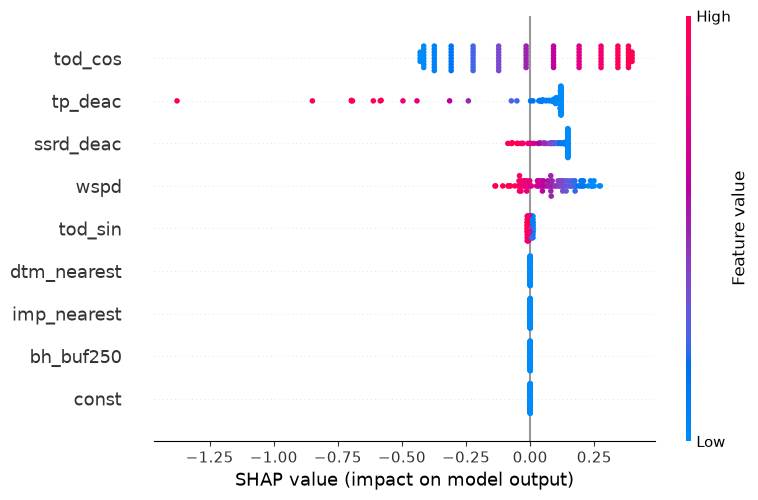

  Repetition 2/3
-- START TIME: 2017-05-01 01:00:00+00:00
added ['tod_sin', 'tod_cos']         recon_val_R²=0.9673
added ['wspd']                       recon_val_R²=0.9677
added ['bh_buf250']                  recon_val_R²=0.9677
LUR: 4 predictors, recon_val_R²=0.9677
Info: No minmax_cols available
const        1.425147
tod_cos      0.737839
wspd        -0.419072
tod_sin      0.007536
bh_buf250    0.000000
dtype: float64


100%|██████████| 100/100 [00:00<00:00, 430.98it/s]


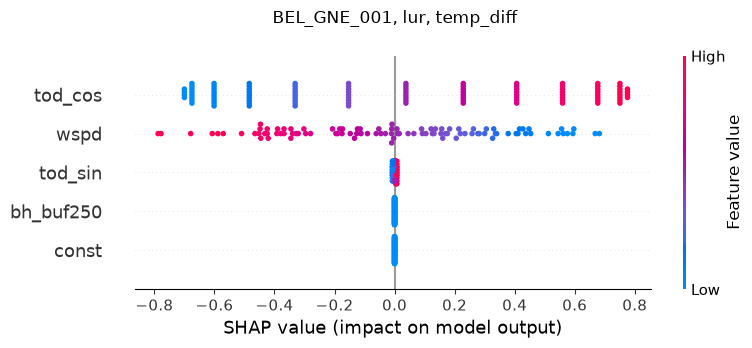

  Repetition 3/3
-- START TIME: 2016-09-07 08:00:00+00:00
added ['tod_sin', 'tod_cos']         recon_val_R²=0.9744
added ['rh']                         recon_val_R²=0.9757
added ['wspd']                       recon_val_R²=0.9758
added ['bh_buf250']                  recon_val_R²=0.9758
added ['imp_buf500']                 recon_val_R²=0.9758
added ssrd                 recon_val_R²=0.9761
added dtm_nearest          recon_val_R²=0.9761
LUR: 8 predictors, recon_val_R²=0.9761
Info: No minmax_cols available
const          0.959311
ssrd           0.298011
tod_cos        0.192881
rh            -0.107385
wspd          -0.039256
tod_sin        0.010774
bh_buf250      0.000000
imp_buf500     0.000000
dtm_nearest    0.000000
dtype: float64


100%|██████████| 100/100 [00:00<00:00, 315.47it/s]


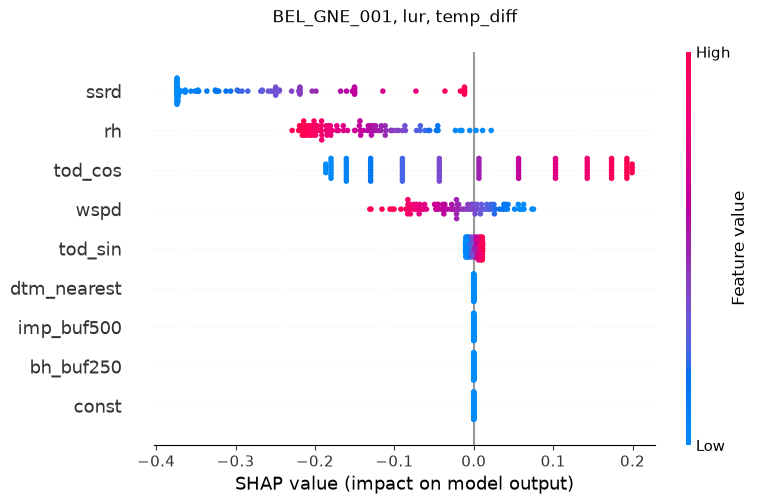

<Figure size 640x480 with 0 Axes>

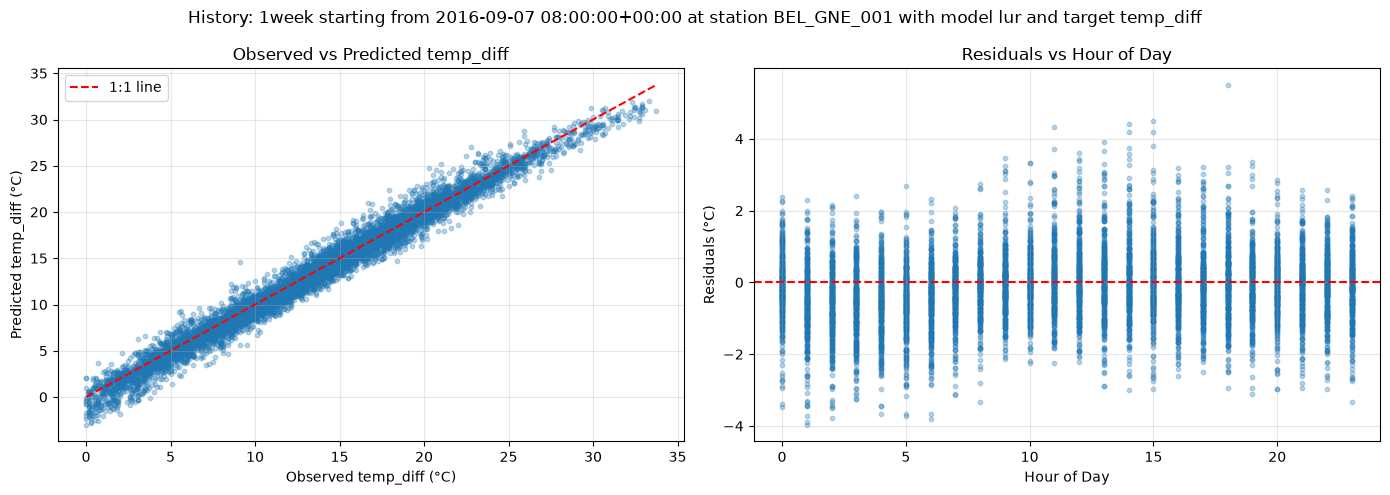


Processing 1month (720 hours)...
  Repetition 1/3
-- START TIME: 2022-01-15 23:00:00+00:00
added ['tod_sin', 'tod_cos']         recon_val_R²=0.9723
added ['t2m_corr']                   recon_val_R²=0.9733
added ['d2m']                        recon_val_R²=0.9767
added ['u10', 'v10']                 recon_val_R²=0.9772
added ['imp_nearest']                recon_val_R²=0.9772
added ssrd                 recon_val_R²=0.9776
added ssrd_deac            recon_val_R²=0.9780
LUR: 9 predictors, recon_val_R²=0.9780
const          1.435881e+00
ssrd_deac     -5.944572e-01
d2m           -4.256428e-01
tod_cos        4.030345e-01
t2m_corr       3.405144e-01
ssrd           1.760289e-01
u10           -7.770813e-02
tod_sin        6.306847e-02
v10           -4.515752e-02
imp_nearest    1.306195e-16
dtype: float64


100%|██████████| 100/100 [00:00<00:00, 114.68it/s]


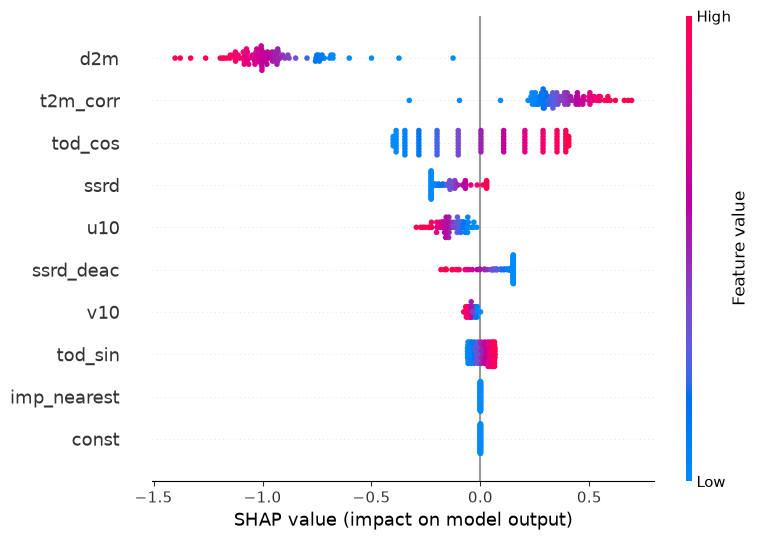

  Repetition 2/3
-- START TIME: 2018-07-22 01:00:00+00:00
added ['tod_sin', 'tod_cos']         recon_val_R²=0.9762
added ['wspd']                       recon_val_R²=0.9763
added tp_deac              recon_val_R²=0.9766
added ssrd                 recon_val_R²=0.9768
LUR: 5 predictors, recon_val_R²=0.9768
tp_deac   -0.990298
const      0.809269
tod_cos    0.406601
tod_sin    0.347644
ssrd       0.297691
wspd      -0.021448
dtype: float64


100%|██████████| 100/100 [00:00<00:00, 333.99it/s]


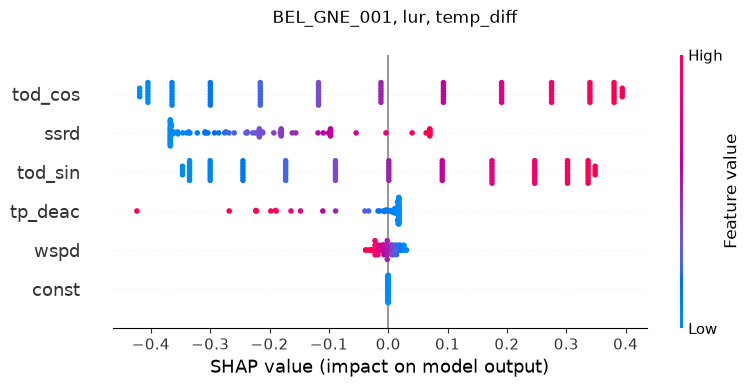

  Repetition 3/3
-- START TIME: 2018-04-30 18:00:00+00:00
added ['tod_sin', 'tod_cos']         recon_val_R²=0.9750
added ['d2m']                        recon_val_R²=0.9760
added ['wspd']                       recon_val_R²=0.9762
added ['imp_nearest']                recon_val_R²=0.9762
added ssrd                 recon_val_R²=0.9768
added tp_deac              recon_val_R²=0.9768
LUR: 7 predictors, recon_val_R²=0.9768
const          6.662525e-01
tod_cos        3.609054e-01
tod_sin        2.723698e-01
ssrd           1.780357e-01
d2m           -1.598908e-01
wspd          -6.062809e-02
tp_deac       -4.956627e-02
imp_nearest   -1.657752e-17
dtype: float64


100%|██████████| 100/100 [00:00<00:00, 230.03it/s]


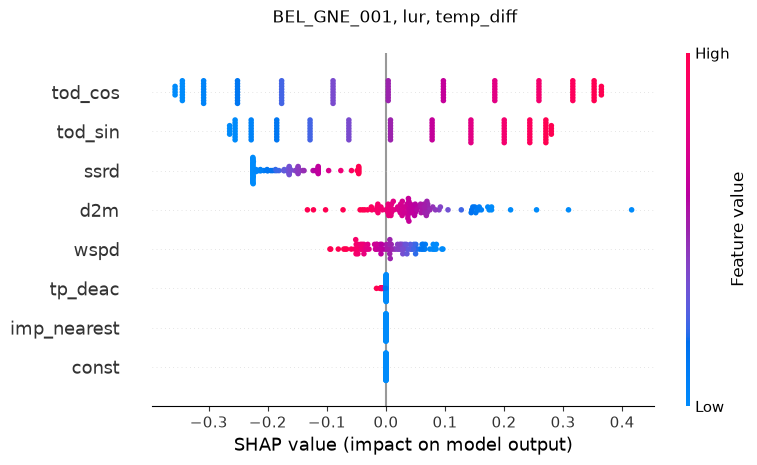

<Figure size 640x480 with 0 Axes>

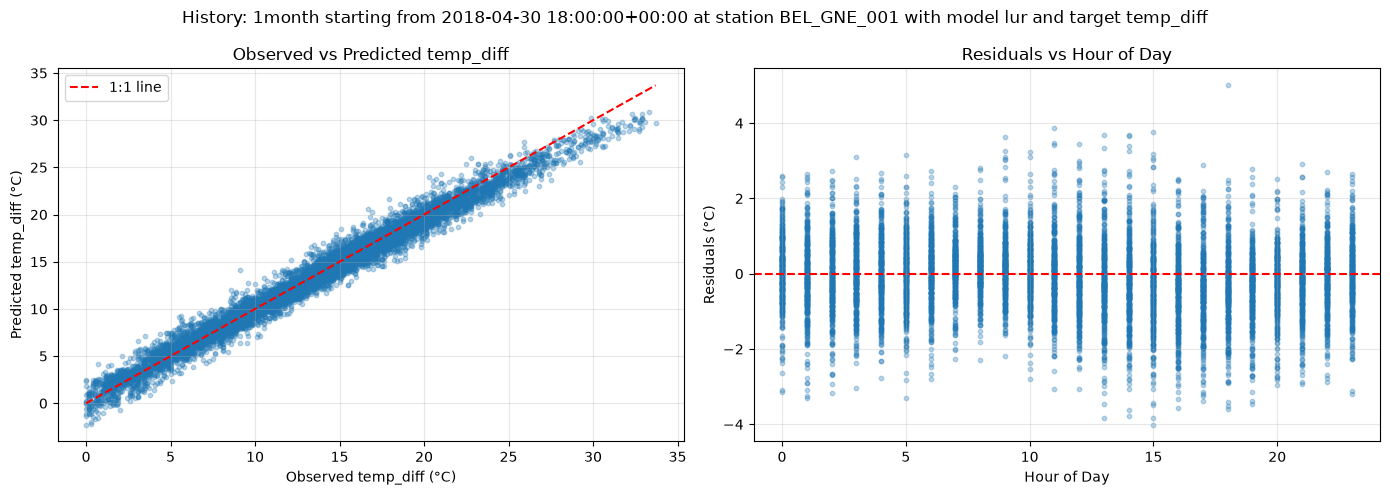


Processing 3months (2160 hours)...
  Repetition 1/3
-- START TIME: 2018-03-02 13:00:00+00:00
added ['tod_sin', 'tod_cos']         recon_val_R²=0.9763
added ['d2m']                        recon_val_R²=0.9765
added ['wspd']                       recon_val_R²=0.9772
added tp_deac              recon_val_R²=0.9773
LUR: 5 predictors, recon_val_R²=0.9773
tp_deac   -2.143216
const      0.971511
tod_cos    0.351296
wspd      -0.145793
d2m       -0.143704
tod_sin   -0.024380
dtype: float64


100%|██████████| 100/100 [00:00<00:00, 343.61it/s]


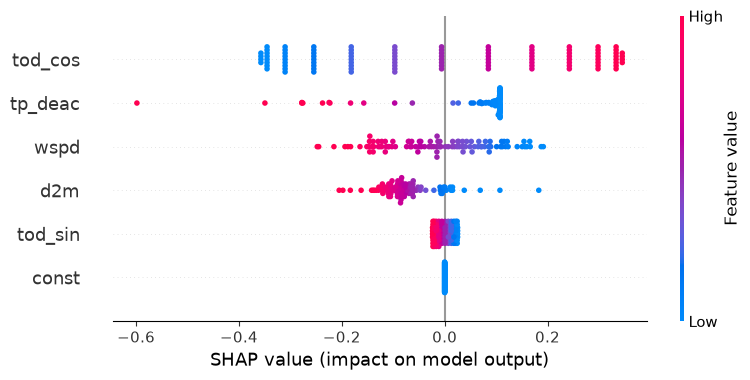

  Repetition 2/3
-- START TIME: 2017-07-17 01:00:00+00:00
added ['tod_sin', 'tod_cos']         recon_val_R²=0.9726
added ['u10', 'v10']                 recon_val_R²=0.9743
added ssrd                 recon_val_R²=0.9748
added sp                   recon_val_R²=0.9748
added tp_deac              recon_val_R²=0.9749
added tp                   recon_val_R²=0.9749
LUR: 8 predictors, recon_val_R²=0.9749
const      0.488946
tod_cos    0.265043
tp_deac   -0.160681
u10       -0.148891
ssrd       0.109600
tod_sin    0.067382
sp         0.025800
v10        0.018488
tp        -0.000208
dtype: float64


100%|██████████| 100/100 [00:00<00:00, 115.82it/s]


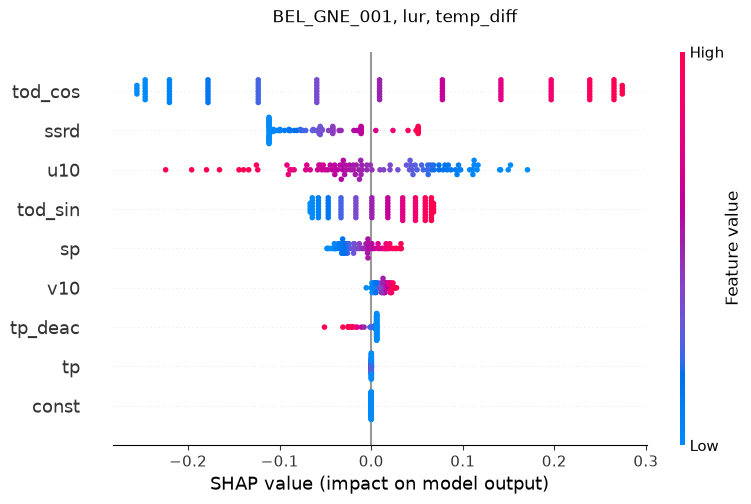

  Repetition 3/3
-- START TIME: 2022-01-02 02:00:00+00:00
added ['tod_sin', 'tod_cos']         recon_val_R²=0.9752
added ['t2m_corr']                   recon_val_R²=0.9753
added ['d2m']                        recon_val_R²=0.9772
added ['wspd']                       recon_val_R²=0.9780
added ['bh_buf250']                  recon_val_R²=0.9780
added ssrd                 recon_val_R²=0.9783
added sp                   recon_val_R²=0.9783
added tp                   recon_val_R²=0.9783
added dtm_nearest          recon_val_R²=0.9783
LUR: 10 predictors, recon_val_R²=0.9783
Info: No minmax_cols available
const          1.138539e+00
tod_cos        4.372726e-01
d2m           -1.993112e-01
t2m_corr       1.430367e-01
wspd          -1.209256e-01
ssrd           5.989331e-02
sp             5.125780e-02
tod_sin        8.568097e-03
tp            -6.985733e-03
bh_buf250     -3.280778e-17
dtm_nearest    0.000000e+00
dtype: float64


100%|██████████| 100/100 [00:00<00:00, 115.87it/s]


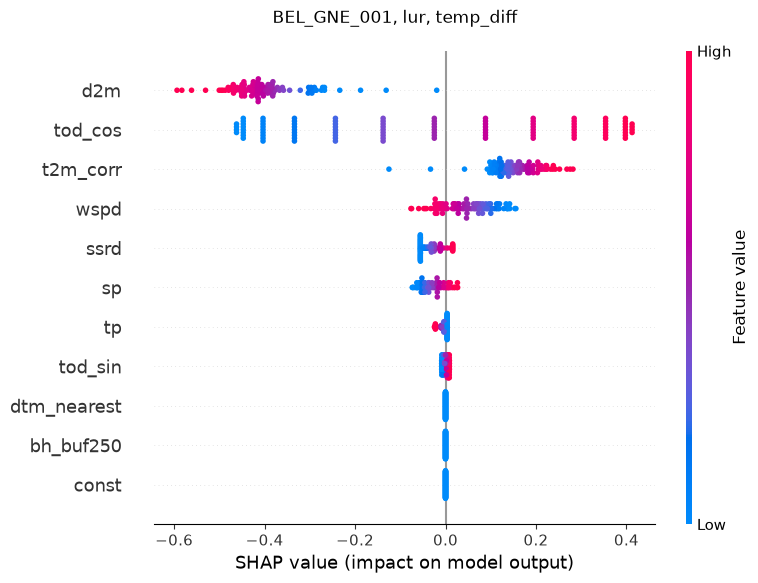

<Figure size 640x480 with 0 Axes>

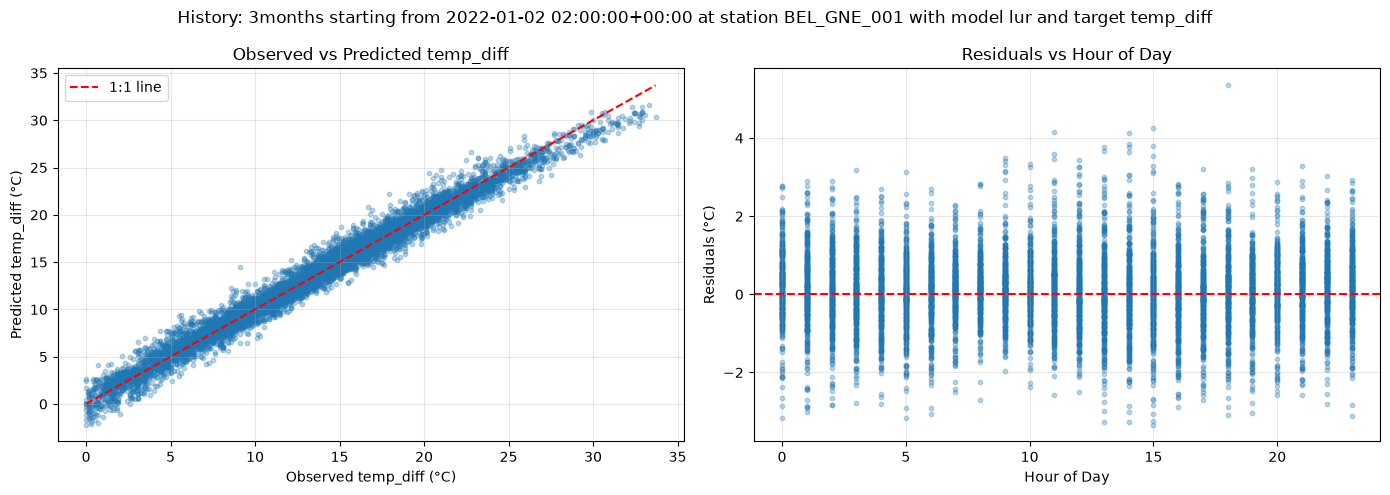


Processing 1year (8760 hours)...
  Repetition 1/3
-- START TIME: 2017-04-06 22:00:00+00:00
added ['tod_sin', 'tod_cos']         recon_val_R²=0.9745
added ['doy_sin', 'doy_cos']         recon_val_R²=0.9750
added ['rh']                         recon_val_R²=0.9751
added ['u10', 'v10']                 recon_val_R²=0.9761
added sp                   recon_val_R²=0.9766
added ssrd                 recon_val_R²=0.9770
added tp_deac              recon_val_R²=0.9771
added ssrd_deac            recon_val_R²=0.9771
LUR: 11 predictors, recon_val_R²=0.9771
tp_deac     -1.209001
const        0.663414
tod_cos      0.276709
doy_sin      0.256591
ssrd_deac   -0.218061
ssrd         0.211353
tod_sin      0.181490
u10         -0.128489
sp           0.092490
v10          0.075635
rh           0.047630
doy_cos     -0.043676
dtype: float64


100%|██████████| 100/100 [00:05<00:00, 19.10it/s]


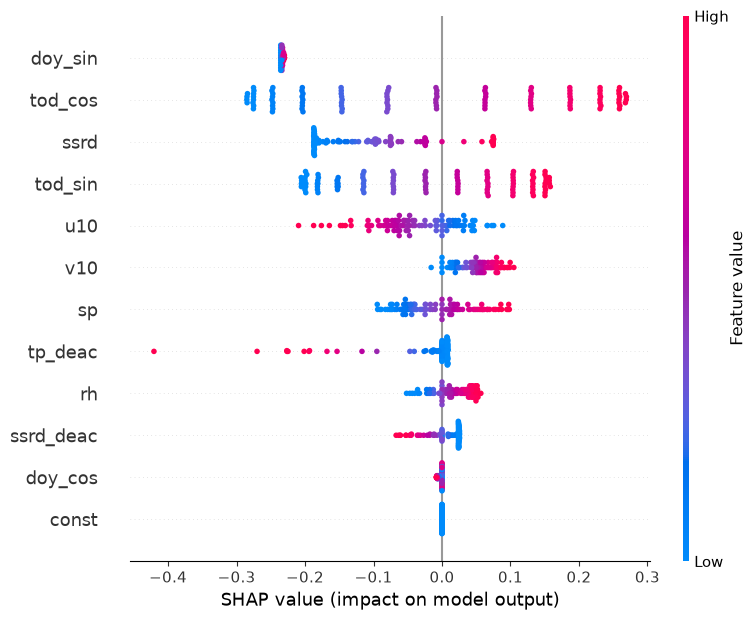

  Repetition 2/3
-- START TIME: 2020-07-29 06:00:00+00:00
added ['tod_sin', 'tod_cos']         recon_val_R²=0.9764
added ['doy_sin', 'doy_cos']         recon_val_R²=0.9771
added ['rh']                         recon_val_R²=0.9774
added ['wspd']                       recon_val_R²=0.9783
added ssrd                 recon_val_R²=0.9786
added sp                   recon_val_R²=0.9787
added ssrd_deac            recon_val_R²=0.9788
added tp_deac              recon_val_R²=0.9788
LUR: 10 predictors, recon_val_R²=0.9788
tp_deac     -0.979095
const        0.954934
ssrd_deac   -0.426613
tod_cos      0.344294
tod_sin      0.209919
ssrd         0.200010
wspd        -0.195547
doy_sin      0.189637
rh          -0.105601
sp           0.057628
doy_cos      0.032649
dtype: float64


100%|██████████| 100/100 [00:02<00:00, 42.78it/s]


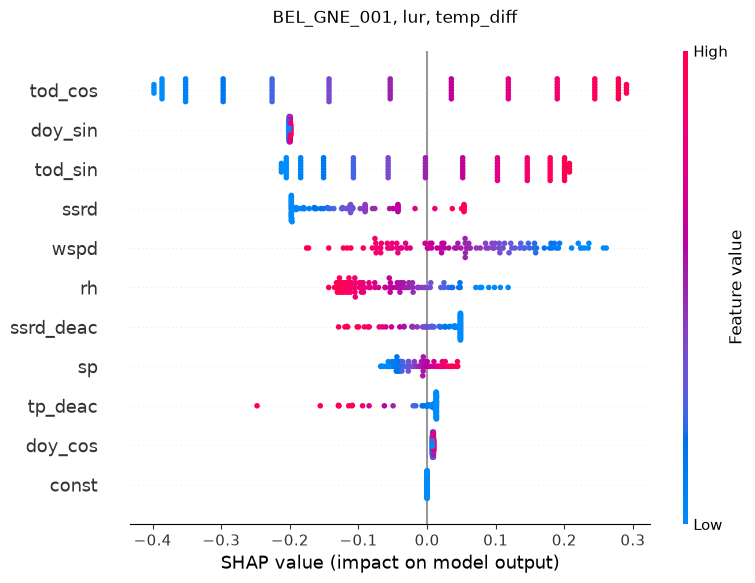

  Repetition 3/3
-- START TIME: 2017-02-23 10:00:00+00:00
added ['tod_sin', 'tod_cos']         recon_val_R²=0.9746
added ['doy_sin', 'doy_cos']         recon_val_R²=0.9751
added ['rh']                         recon_val_R²=0.9753
added ['u10', 'v10']                 recon_val_R²=0.9763
added ['tcd_buf750']                 recon_val_R²=0.9763
added ['imp_buf750']                 recon_val_R²=0.9763
added ssrd                 recon_val_R²=0.9767
added sp                   recon_val_R²=0.9770
added tp_deac              recon_val_R²=0.9771
added dtm_nearest          recon_val_R²=0.9771
LUR: 13 predictors, recon_val_R²=0.9771
tp_deac       -1.213826e+00
const          6.356697e-01
tod_cos        3.354250e-01
doy_sin        2.528046e-01
ssrd           1.860576e-01
tod_sin        1.525969e-01
u10           -1.396711e-01
v10            7.676559e-02
sp             7.407990e-02
rh             4.584832e-02
doy_cos       -1.685990e-02
tcd_buf750     2.632954e-16
imp_buf750     3.264306e-17
dtm_near

100%|██████████| 100/100 [00:02<00:00, 33.81it/s]


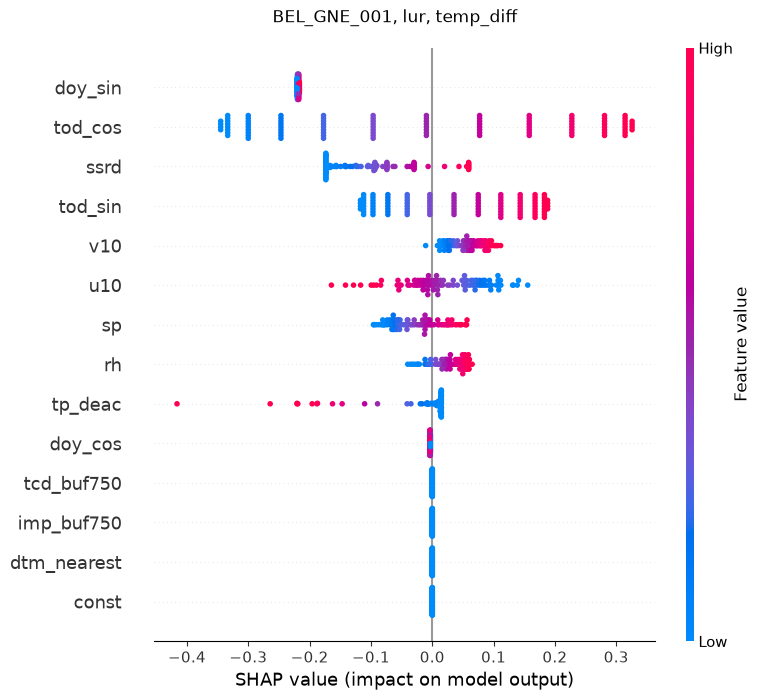

<Figure size 640x480 with 0 Axes>

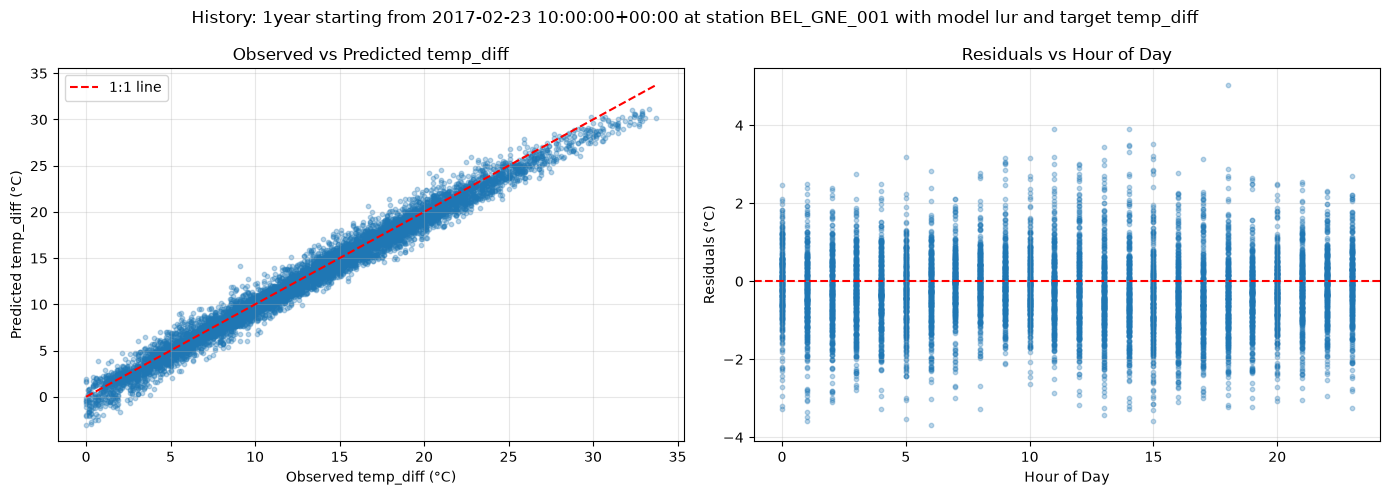


Processing 3years (26280 hours)...
  Repetition 1/3
-- START TIME: 2018-09-15 06:00:00+00:00
added ['tod_sin', 'tod_cos']         recon_val_R²=0.9764
added ['doy_sin', 'doy_cos']         recon_val_R²=0.9770
added ['rh']                         recon_val_R²=0.9773
added ['wspd']                       recon_val_R²=0.9782
added ssrd                 recon_val_R²=0.9785
added sp                   recon_val_R²=0.9786
added ssrd_deac            recon_val_R²=0.9786
added tp_deac              recon_val_R²=0.9787
LUR: 10 predictors, recon_val_R²=0.9787
tp_deac     -1.431350
const        0.926569
ssrd_deac   -0.509349
tod_cos      0.273297
doy_sin      0.259072
ssrd         0.177177
tod_sin      0.175870
wspd        -0.167653
rh          -0.100911
sp           0.058815
doy_cos      0.050791
dtype: float64


100%|██████████| 100/100 [00:02<00:00, 36.32it/s]


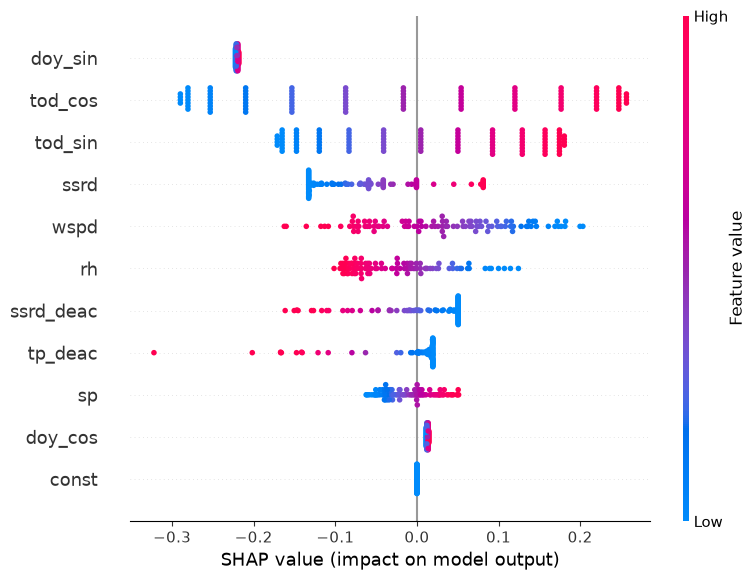

  Repetition 2/3
-- START TIME: 2018-01-28 02:00:00+00:00
added ['tod_sin', 'tod_cos']         recon_val_R²=0.9763
added ['doy_sin', 'doy_cos']         recon_val_R²=0.9769
added ['rh']                         recon_val_R²=0.9772
added ['wspd']                       recon_val_R²=0.9780
added ['bh_buf250']                  recon_val_R²=0.9780
added ssrd                 recon_val_R²=0.9783
added sp                   recon_val_R²=0.9784
added ssrd_deac            recon_val_R²=0.9785
added tp_deac              recon_val_R²=0.9785
LUR: 11 predictors, recon_val_R²=0.9785
tp_deac     -1.302159e+00
const        8.750737e-01
ssrd_deac   -3.326093e-01
tod_cos      3.039647e-01
doy_sin      2.339242e-01
tod_sin      1.844489e-01
ssrd         1.569423e-01
wspd        -1.519324e-01
doy_cos      1.233616e-01
rh          -1.217524e-01
sp           6.401748e-02
bh_buf250   -6.790649e-16
dtype: float64


100%|██████████| 100/100 [00:02<00:00, 35.19it/s]


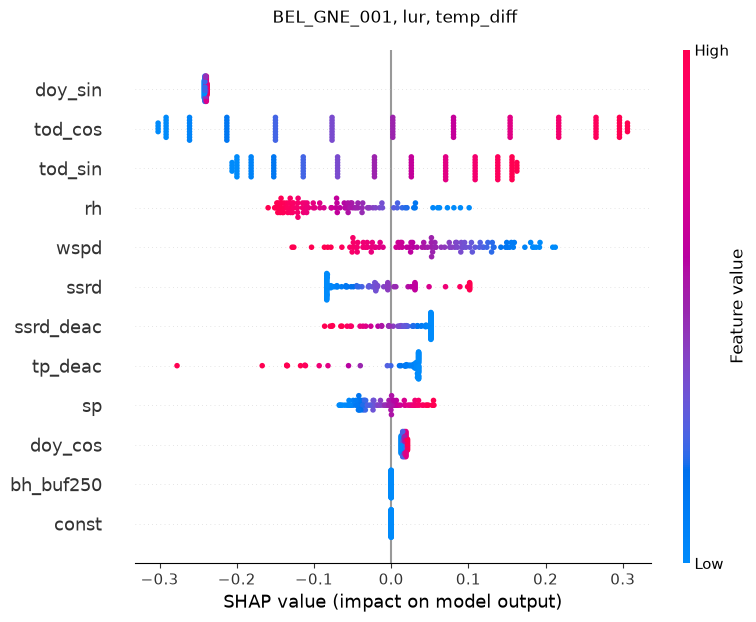

  Repetition 3/3
-- START TIME: 2016-08-13 10:00:00+00:00
added ['tod_sin', 'tod_cos']         recon_val_R²=0.9756
added ['doy_sin', 'doy_cos']         recon_val_R²=0.9763
added ['t2m']                        recon_val_R²=0.9763
added ['d2m']                        recon_val_R²=0.9767
added ['u10', 'v10']                 recon_val_R²=0.9773
added ssrd                 recon_val_R²=0.9776
added sp                   recon_val_R²=0.9778
added tp_deac              recon_val_R²=0.9779
added ssrd_deac            recon_val_R²=0.9779
added dtm_nearest          recon_val_R²=0.9779
LUR: 13 predictors, recon_val_R²=0.9779
tp_deac       -1.088152
const          0.776239
tod_cos        0.321216
ssrd_deac     -0.293966
doy_sin        0.234578
tod_sin        0.192811
ssrd           0.185786
d2m           -0.149700
sp             0.143250
u10           -0.135879
v10            0.131580
t2m            0.126300
doy_cos       -0.044694
dtm_nearest    0.000000
dtype: float64


100%|██████████| 100/100 [00:06<00:00, 15.76it/s]


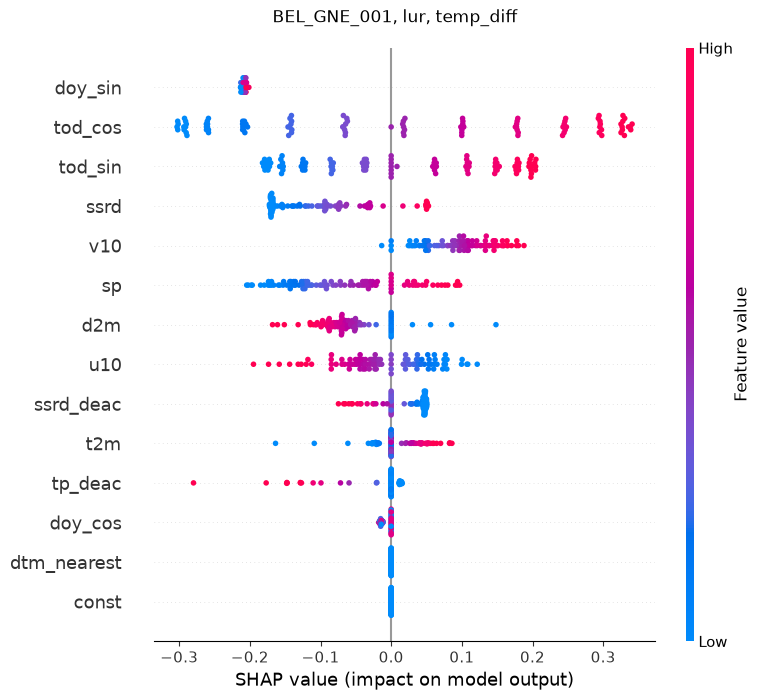

<Figure size 640x480 with 0 Axes>

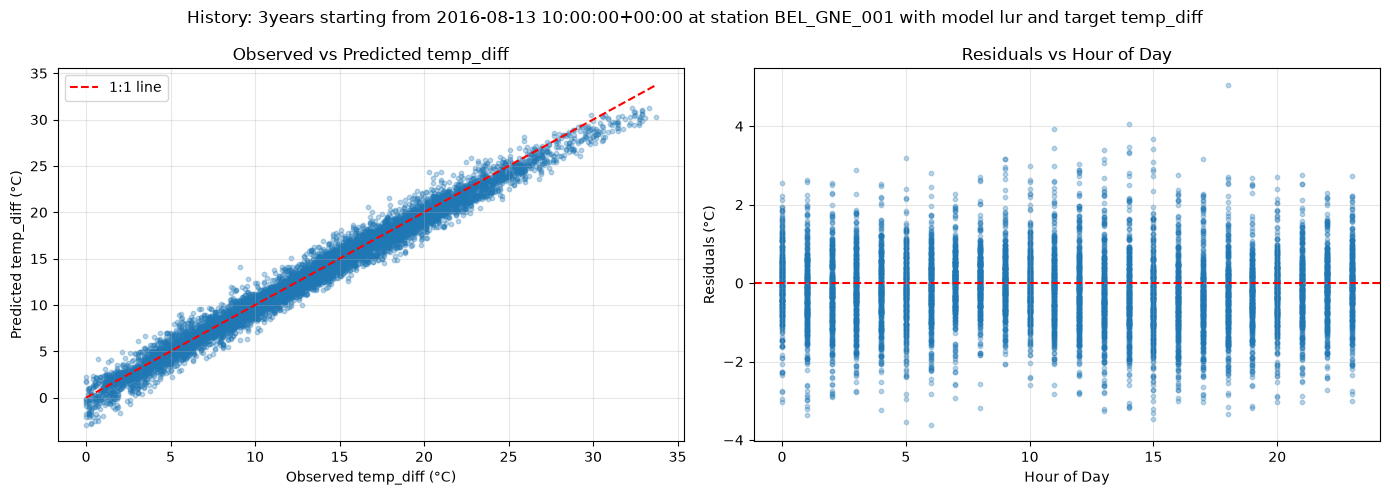


Processing 6years (52560 hours)...
  Repetition 1/3
-- START TIME: 2016-07-01 01:00:00+00:00
added ['tod_sin', 'tod_cos']         recon_val_R²=0.9762
added ['doy_sin', 'doy_cos']         recon_val_R²=0.9768
added ['rh']                         recon_val_R²=0.9771
added ['wspd']                       recon_val_R²=0.9778
added ['imp_buf50']                  recon_val_R²=0.9778
added ssrd                 recon_val_R²=0.9782
added sp                   recon_val_R²=0.9782
added ssrd_deac            recon_val_R²=0.9783
added tp_deac              recon_val_R²=0.9783
added dtm_nearest          recon_val_R²=0.9783
LUR: 12 predictors, recon_val_R²=0.9783
tp_deac       -2.494632e+00
const          8.619548e-01
ssrd_deac     -4.093039e-01
tod_cos        3.027556e-01
doy_sin        2.425884e-01
tod_sin        1.971865e-01
ssrd           1.834066e-01
wspd          -1.439328e-01
rh            -1.099221e-01
sp             5.699175e-02
doy_cos        4.475185e-02
imp_buf50     -5.932509e-15
dtm_neares

100%|██████████| 100/100 [00:02<00:00, 34.58it/s]


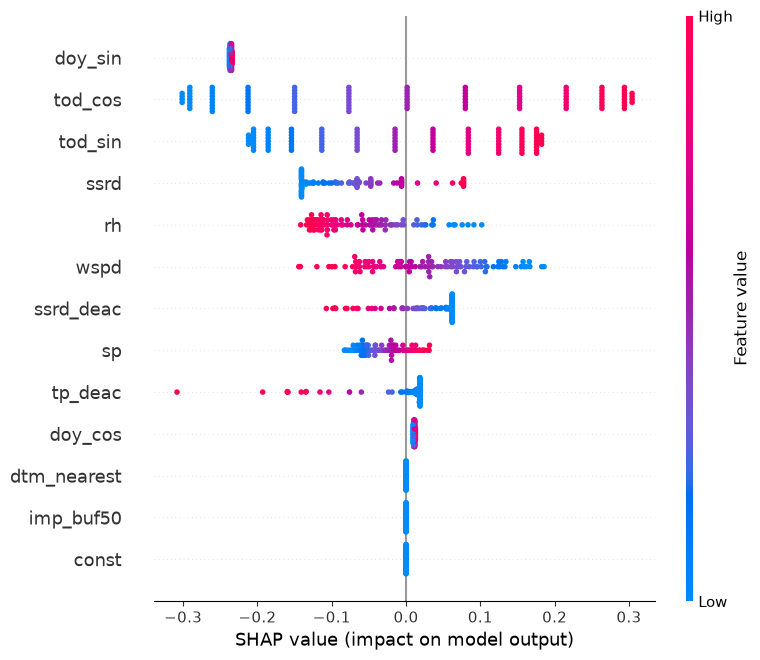

  Repetition 2/3
-- START TIME: 2016-07-01 01:00:00+00:00
added ['tod_sin', 'tod_cos']         recon_val_R²=0.9762
added ['doy_sin', 'doy_cos']         recon_val_R²=0.9768
added ['rh']                         recon_val_R²=0.9771
added ['wspd']                       recon_val_R²=0.9778
added ['imp_buf50']                  recon_val_R²=0.9778
added ssrd                 recon_val_R²=0.9782
added sp                   recon_val_R²=0.9782
added ssrd_deac            recon_val_R²=0.9783
added tp_deac              recon_val_R²=0.9783
added dtm_nearest          recon_val_R²=0.9783
LUR: 12 predictors, recon_val_R²=0.9783
tp_deac       -2.494632e+00
const          8.619548e-01
ssrd_deac     -4.093039e-01
tod_cos        3.027556e-01
doy_sin        2.425884e-01
tod_sin        1.971865e-01
ssrd           1.834066e-01
wspd          -1.439328e-01
rh            -1.099221e-01
sp             5.699175e-02
doy_cos        4.475185e-02
imp_buf50     -5.932509e-15
dtm_nearest    0.000000e+00
dtype: float64


100%|██████████| 100/100 [00:02<00:00, 34.16it/s]


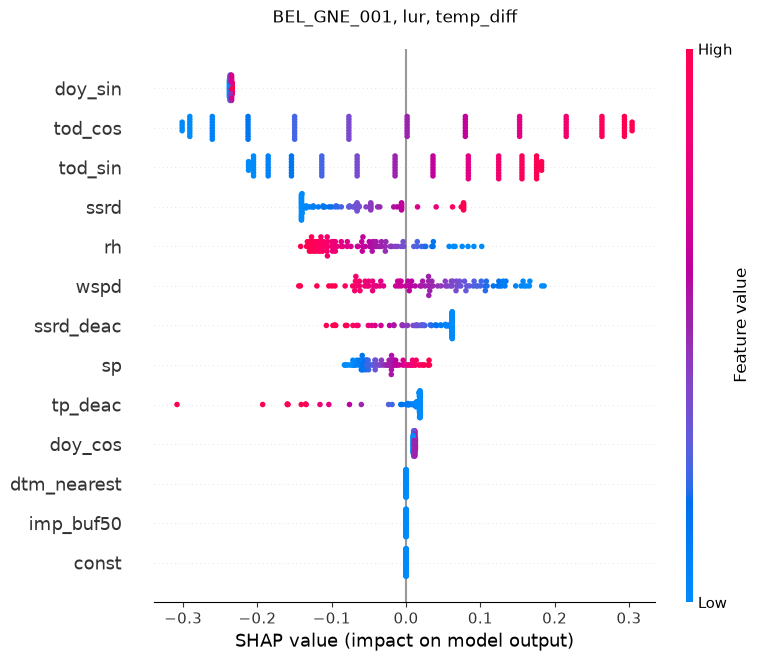

  Repetition 3/3
-- START TIME: 2016-07-01 01:00:00+00:00
added ['tod_sin', 'tod_cos']         recon_val_R²=0.9762
added ['doy_sin', 'doy_cos']         recon_val_R²=0.9768
added ['rh']                         recon_val_R²=0.9771
added ['wspd']                       recon_val_R²=0.9778
added ['imp_buf50']                  recon_val_R²=0.9778
added ssrd                 recon_val_R²=0.9782
added sp                   recon_val_R²=0.9782
added ssrd_deac            recon_val_R²=0.9783
added tp_deac              recon_val_R²=0.9783
added dtm_nearest          recon_val_R²=0.9783
LUR: 12 predictors, recon_val_R²=0.9783
tp_deac       -2.494632e+00
const          8.619548e-01
ssrd_deac     -4.093039e-01
tod_cos        3.027556e-01
doy_sin        2.425884e-01
tod_sin        1.971865e-01
ssrd           1.834066e-01
wspd          -1.439328e-01
rh            -1.099221e-01
sp             5.699175e-02
doy_cos        4.475185e-02
imp_buf50     -5.932509e-15
dtm_nearest    0.000000e+00
dtype: float64


100%|██████████| 100/100 [00:02<00:00, 34.09it/s]


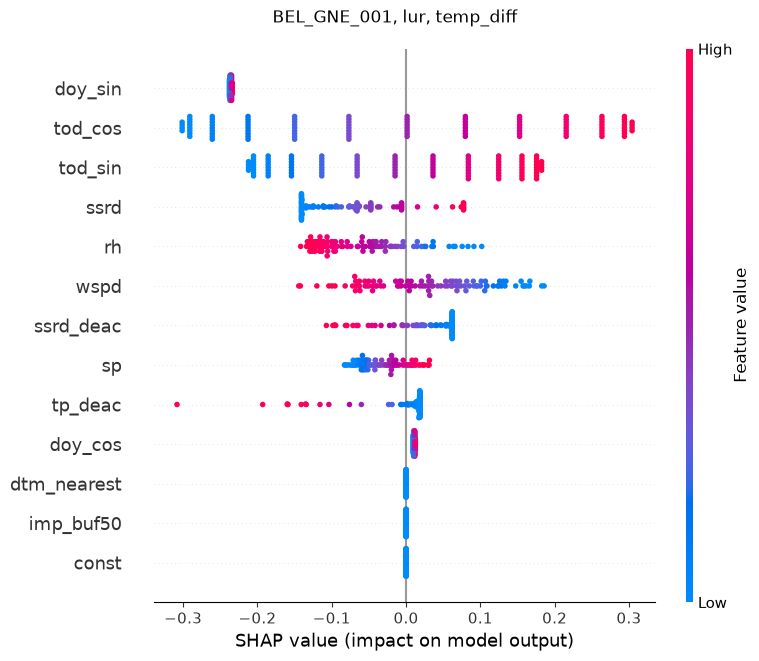

<Figure size 640x480 with 0 Axes>

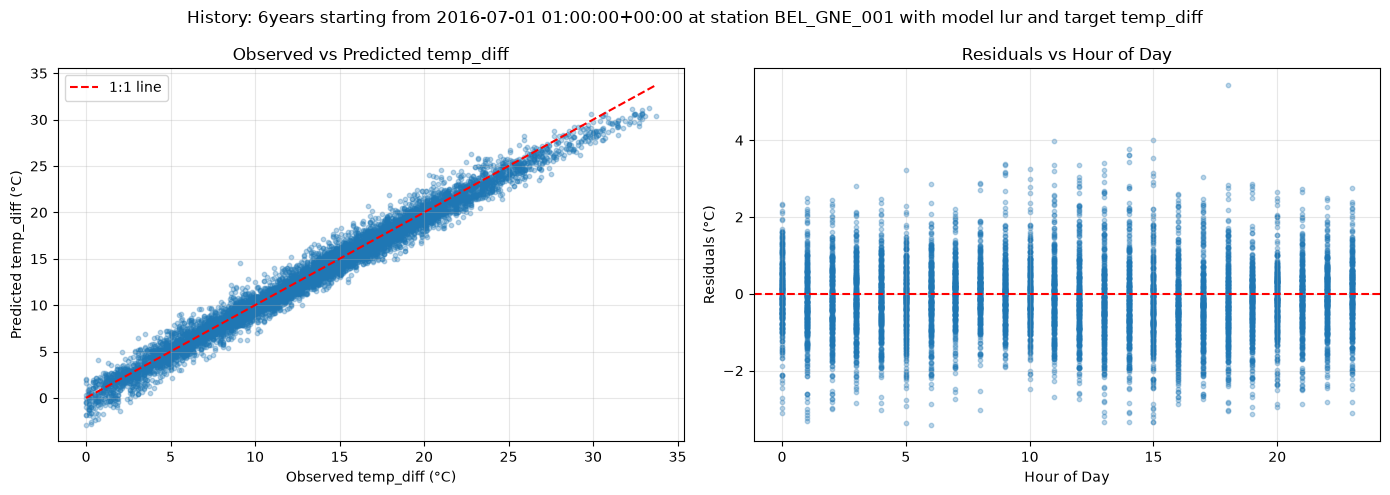

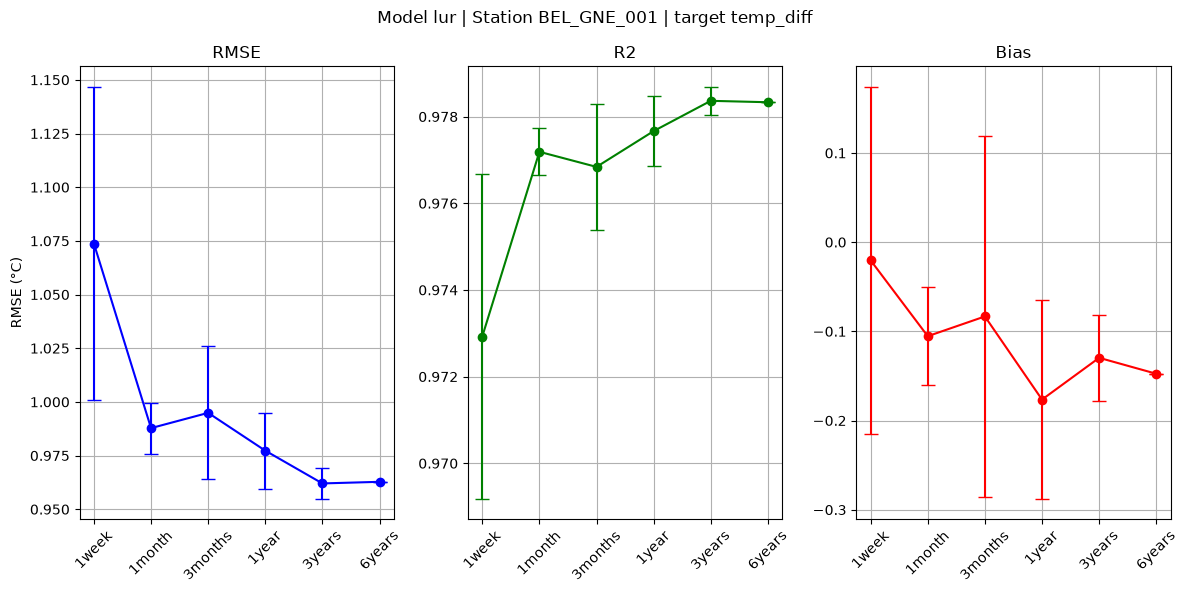


Summary of Results:

Trained with Features ['tod_sin', 'tod_cos', 'doy_sin', 'doy_cos', 'rh', 'wspd', 'imp_buf50', 'ssrd', 'sp', 'ssrd_deac', 'tp_deac', 'dtm_nearest']
History      RMSE Mean  RMSE Std   R2 Mean    R2 Std     Bias Mean 
1week        1.07       0.07       0.97       0.00       -0.02     
1month       0.99       0.01       0.98       0.00       -0.11     
3months      0.99       0.03       0.98       0.00       -0.08     
1year        0.98       0.02       0.98       0.00       -0.18     
3years       0.96       0.01       0.98       0.00       -0.13     
6years       0.96       0.00       0.98       0.00       -0.15     


In [20]:
results = train_and_explain_model(df, model_name="lur", target="temp_diff", city="ghent", station="BEL_GNE_001")

In [21]:
dfs =  []
for hl in results:  # loop over history_length sorted entries
    for entry in results[hl]["cyclic_effects"]:
        impact_tod = entry["impact_tod"]

        df = pd.DataFrame({"tod":impact_tod.keys(), "impact":impact_tod.values()})
        df["history_length"] = hl
        dfs.append(df)

df = pd.concat(dfs).reset_index().drop(columns=["index"])
# df.groupby(["history_len", "tod"]).mean()
df

,tod,impact,history_length
0,0,0.413285,1week
1,1,0.396251,1week
2,2,0.352212,1week
3,3,0.284172,1week
4,4,0.196765,1week
...,...,...,...
427,19,-0.112109,6years
428,20,-0.019391,6years
429,21,0.074649,6years
430,22,0.163601,6years


1week


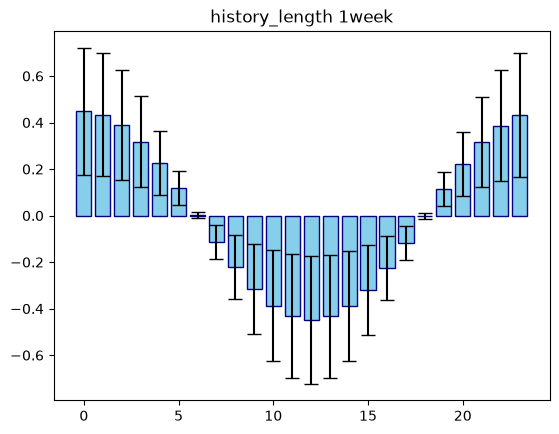

1month


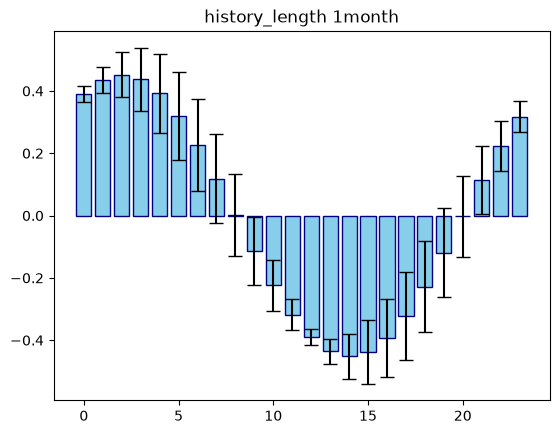

3months


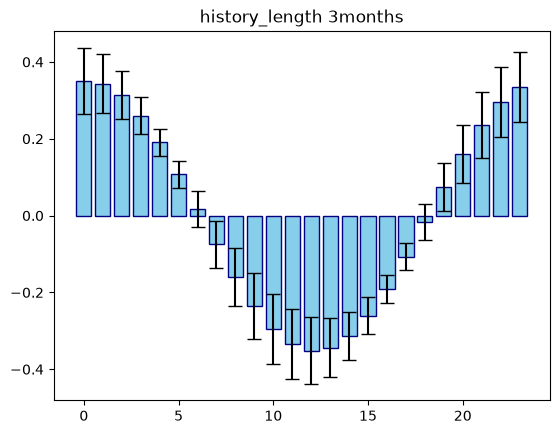

1year


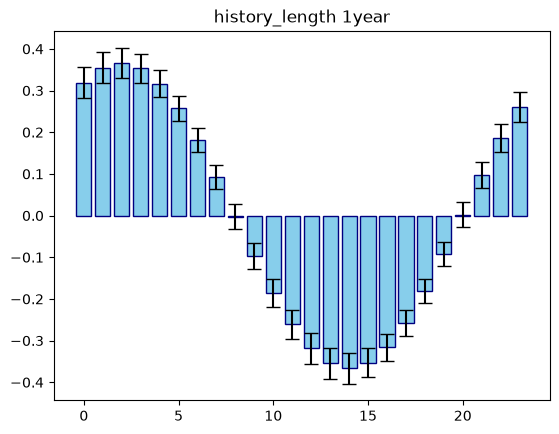

3years


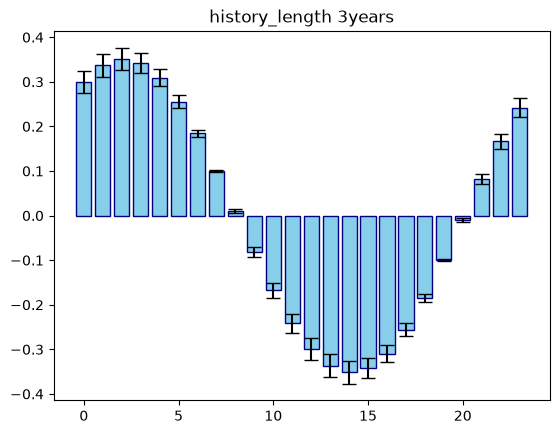

6years


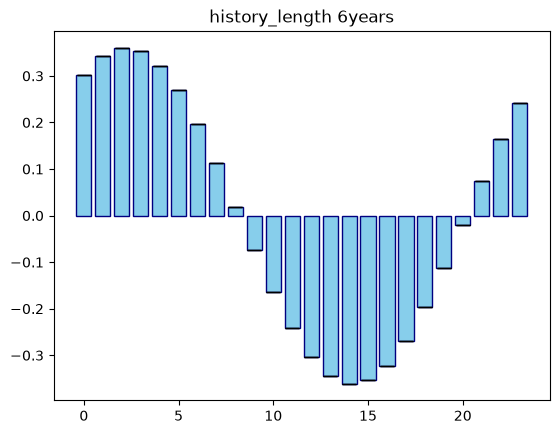

In [22]:
for hl in df["history_length"].unique():
        print(hl)
        tod_stats = df[df["history_length"]== hl].groupby('tod')['impact'].agg(['mean', 'std']).reset_index()
        

        # Create bar plot with error bars
        plt.bar(tod_stats['tod'],
                tod_stats['mean'],
                yerr=tod_stats['std'],
                capsize=5,
                color='skyblue',
                edgecolor='navy',
                )
        plt.title(f"history_length {hl}")
        plt.show()